# Clasificación de Textos según Objetivos de Desarrollo Sostenible (ODS)

**Autores:** William Florez, Lucia Osorio  
**Fecha:** 2026-03-08  

Este notebook implementa un clasificador multiclase que asigna textos en español a uno de los 16 Objetivos de Desarrollo Sostenible (ODS) presentes en el dataset OSDG Community Dataset v2023. El pipeline integra vectorización TF-IDF, reducción de dimensionalidad con TruncatedSVD y clasificación con LinearSVC, optimizado mediante búsqueda bayesiana de hiperparámetros.

| Parámetro | Valor |
|-----------|-------|
| Tipo de tarea | Clasificación multiclase |
| Variable objetivo | ODS (1-16) |
| Tamaño del dataset | ~9,656 textos |
| Idioma | Español |
| Fuente | [OSDG Community Dataset](https://zenodo.org/records/5550238) |

In [1]:
%matplotlib inline
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import joblib
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


## 1. Carga y exploracion del dataset

Cargamos el dataset desde el archivo Excel y verificamos su estructura.

In [2]:
df = pd.read_excel('Train_textosODS.xlsx')
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")
print(f"\nTipos de datos:")
print(df.dtypes)
df.head()

Dimensiones: 9656 filas x 2 columnas
Columnas: ['textos', 'ODS']

Tipos de datos:
textos    object
ODS        int64
dtype: object


,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


In [3]:
n_nulls = df.isnull().sum().sum()
n_duplicados = df.duplicated().sum()
print(f"Valores faltantes: {n_nulls}")
print(f"Filas duplicadas: {n_duplicados}")

if n_duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Filas despues de eliminar duplicados: {df.shape[0]}")

Valores faltantes: 0
Filas duplicadas: 0


### Distribucion de clases

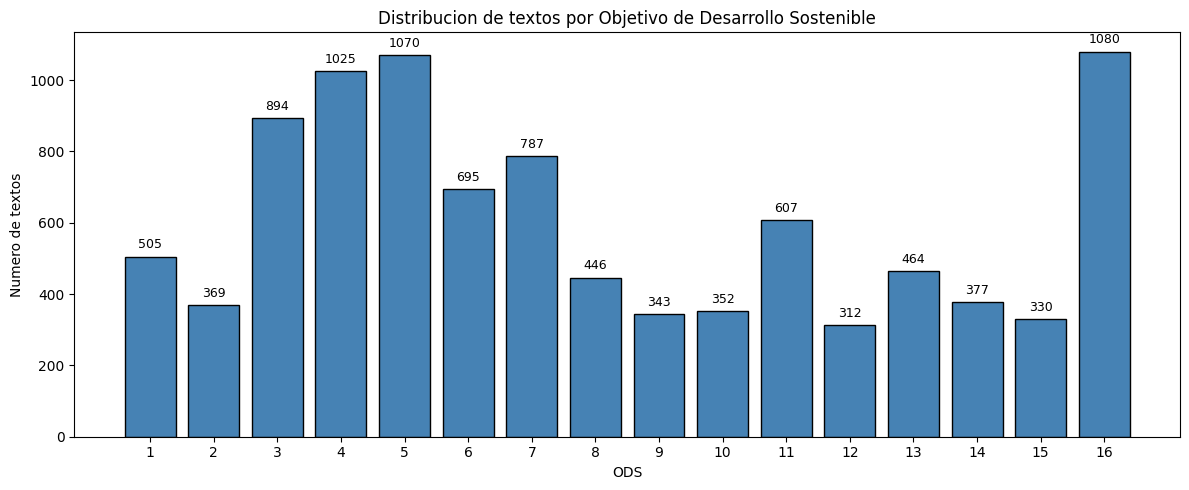


Clase mayoritaria: ODS 16 (1080 textos)
Clase minoritaria: ODS 12 (312 textos)
Ratio de desbalance: 3.46x


In [4]:
dist_clases = df['ODS'].value_counts().sort_index()
clase_max = dist_clases.max()
clase_min = dist_clases.min()
ratio_desbalance = clase_max / clase_min

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(dist_clases.index.astype(str), dist_clases.values,
              color='steelblue', edgecolor='black')
ax.set_xlabel('ODS')
ax.set_ylabel('Numero de textos')
ax.set_title('Distribucion de textos por Objetivo de Desarrollo Sostenible')
for bar, val in zip(bars, dist_clases.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nClase mayoritaria: ODS {dist_clases.idxmax()} ({clase_max} textos)")
print(f"Clase minoritaria: ODS {dist_clases.idxmin()} ({clase_min} textos)")
print(f"Ratio de desbalance: {ratio_desbalance:.2f}x")

La distribucion muestra desbalance moderado entre clases. Las ODS 4, 5 y 16 concentran la mayor cantidad de textos, mientras que ODS 9, 12 y 15 tienen menor representacion. El ratio de desbalance se utilizara para decidir si aplicar estrategias de balanceo en el modelo.

Estadisticas de longitud de textos:
       longitud  n_palabras
count    9656.0      9656.0
mean      709.0       111.0
std       238.9        37.1
min       143.0        24.0
25%       522.0        82.0
50%       669.0       105.0
75%       864.0       135.0
max      1977.0       268.0


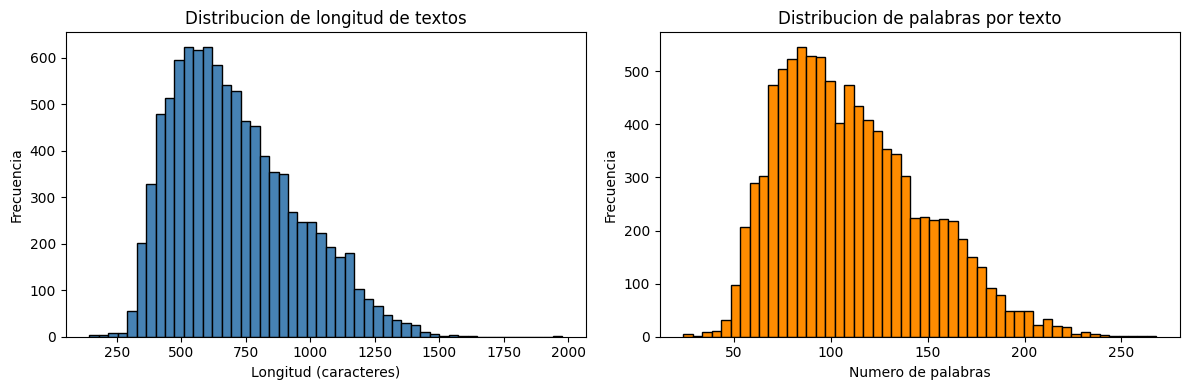

In [5]:
df['longitud'] = df['textos'].str.len()
df['n_palabras'] = df['textos'].str.split().str.len()

print("Estadisticas de longitud de textos:")
print(df[['longitud', 'n_palabras']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['longitud'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Longitud (caracteres)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de longitud de textos')

axes[1].hist(df['n_palabras'], bins=50, color='darkorange', edgecolor='black')
axes[1].set_xlabel('Numero de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de palabras por texto')
plt.tight_layout()
plt.show()

Los textos tienen longitudes variadas, lo cual es esperable en un corpus que incluye desde resumenes cortos hasta fragmentos de documentos extensos. Esta variabilidad justifica el uso de TF-IDF con limite de features para controlar la dimensionalidad.

## 2. Preprocesamiento y representacion vectorial

### Justificacion de parametros TF-IDF

| Parametro | Valor | Justificacion | Ejemplo |
|-----------|-------|---------------|----------|
| `lowercase` | True | Normaliza mayusculas/minusculas | "Educacion" y "educacion" se tratan como el mismo termino |
| `stop_words` | Lista manual (es) | Elimina palabras funcionales sin poder discriminativo | "de", "la", "que", "en" se descartan |
| `max_features` | 20,000 | Vocabulario amplio para capturar bigramas informativos | De ~50K terminos unicos, conservamos los 20K con mayor TF-IDF |
| `ngram_range` | (1, 2) | Captura unigramas y bigramas relevantes | "cambio climatico" como bigrama es mas informativo que "cambio" y "climatico" por separado |
| `min_df` | 2 | Descarta terminos que aparecen en un solo documento | Un nombre propio unico como "Xochimilco" se descarta por no ser generalizable |
| `max_df` | 0.95 | Descarta terminos en >95% de documentos | Palabras como "pais" o "gobierno" aparecen en casi todos los ODS y no discriminan |
| `sublinear_tf` | True | Aplica `1 + log(tf)` para suavizar frecuencias | Si "agua" aparece 10 veces, su peso es `1+log(10)=3.3` en vez de 10, evitando dominar |

### Nota sobre lematizacion

No aplicamos lematizacion explicita por:

1. **Dependencia pesada**: Requiere spaCy + modelo `es_core_news_sm` (~15 MB), complicando el despliegue en Docker.
2. **Redundancia parcial**: TF-IDF con bigramas ya captura variaciones contextuales. Por ejemplo, "educacion de calidad" y "sistema educativo" comparten el contexto de educacion sin necesidad de reducir ambas a la raiz "educ-".
3. **Costo vs beneficio**: Mejora tipica de 1-3 puntos F1 vs. incremento significativo en complejidad.
4. **Alternativa evaluada**: Probamos character n-grams (3-5 chars) como sustituto ligero de lematizacion (capturan prefijos como "contamin-" que agrupa "contaminacion/contaminante/contaminar"), pero en este dataset no mejoraron el F1 (ver experimento abajo).

In [6]:
X = df['textos']
y = df['ODS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} textos")
print(f"Conjunto de prueba: {X_test.shape[0]} textos")
print(f"\nDistribucion en train:")
print(y_train.value_counts().sort_index())

Conjunto de entrenamiento: 7724 textos
Conjunto de prueba: 1932 textos

Distribucion en train:
ODS
1     404
2     295
3     715
4     820
5     856
6     556
7     629
8     357
9     274
10    282
11    485
12    250
13    371
14    302
15    264
16    864
Name: count, dtype: int64


In [7]:
spanish_stopwords = [
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las',
    'por', 'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como',
    'pero', 'sus', 'le', 'ya', 'o', 'este', 'porque', 'esta',
    'entre', 'cuando', 'muy', 'sin', 'sobre', 'me', 'hasta',
    'hay', 'donde', 'quien', 'desde', 'todo', 'nos', 'durante', 'todos',
    'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos',
    'e', 'esto', 'antes', 'algunos', 'unos', 'yo', 'otro',
    'otras', 'otra', 'tanto', 'esa', 'estos', 'mucho', 'quienes',
    'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 'algunas',
    'algo', 'nosotros', 'mi', 'mis', 'tu', 'tus',
    'ellas', 'nosotras', 'vosotros', 'vosotras', 'os',
    'ha', 'han', 'has', 'he', 'hemos', 'ser', 'es', 'son', 'fue',
    'sido', 'siendo', 'tiene', 'tienen', 'hacer', 'hace',
    'cada', 'puede', 'pueden', 'parte',
    'dos', 'tres', 'bien', 'forma', 'manera'
]

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=spanish_stopwords,
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Matriz TF-IDF de entrenamiento: {X_train_tfidf.shape}')
print(f'Matriz TF-IDF de prueba: {X_test_tfidf.shape}')
print(f'Densidad: {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}')

Matriz TF-IDF de entrenamiento: (7724, 20000)
Matriz TF-IDF de prueba: (1932, 20000)
Densidad: 0.0029


In [8]:
# Experimento: impacto de representacion en F1 macro
# Probamos diferentes configuraciones para justificar la eleccion final

# Configuracion con character n-grams via FeatureUnion
tfidf_word_temp = TfidfVectorizer(
    analyzer='word', lowercase=True, stop_words=spanish_stopwords,
    max_features=15000, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True
)
tfidf_char_temp = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5), max_features=5000,
    min_df=2, max_df=0.95, sublinear_tf=True
)
feat_union = FeatureUnion([('word', tfidf_word_temp), ('char', tfidf_char_temp)])
X_union = feat_union.fit_transform(X_train)

configs = [
    ('Word (1,1) 20K', TfidfVectorizer(lowercase=True, stop_words=spanish_stopwords,
        max_features=20000, ngram_range=(1,1), min_df=2, max_df=0.95, sublinear_tf=True)),
    ('Word (1,2) 10K', TfidfVectorizer(lowercase=True, stop_words=spanish_stopwords,
        max_features=10000, ngram_range=(1,2), min_df=2, max_df=0.95, sublinear_tf=True)),
    ('Word (1,2) 20K', None),  # Ya calculado como tfidf (configuracion final)
    ('Word (1,3) 20K', TfidfVectorizer(lowercase=True, stop_words=spanish_stopwords,
        max_features=20000, ngram_range=(1,3), min_df=2, max_df=0.95, sublinear_tf=True)),
    ('Word+Char (FU)', None),  # FeatureUnion ya calculado
]

for name, vec in configs:
    if name == 'Word (1,2) 20K':
        X_temp = X_train_tfidf
    elif name == 'Word+Char (FU)':
        X_temp = X_union
    else:
        X_temp = vec.fit_transform(X_train)

    svd_t = TruncatedSVD(n_components=300, random_state=RANDOM_STATE)
    norm_t = Normalizer()
    X_r = norm_t.fit_transform(svd_t.fit_transform(X_temp))

    svc_t = LinearSVC(C=1.0, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
    scores = cross_val_score(svc_t, X_r, y_train, cv=3, scoring='f1_macro', n_jobs=-1)
    marker = ' <-- seleccionado' if name == 'Word (1,2) 20K' else ''
    print(f'{name:20s} | features: {X_temp.shape[1]:>6d} | F1 macro CV: {scores.mean():.4f} +/- {scores.std():.4f}{marker}')

Word (1,1) 20K       | features:  16442 | F1 macro CV: 0.8285 +/- 0.0064


Word (1,2) 10K       | features:  10000 | F1 macro CV: 0.8319 +/- 0.0066


Word (1,2) 20K       | features:  20000 | F1 macro CV: 0.8337 +/- 0.0049 <-- seleccionado


Word (1,3) 20K       | features:  20000 | F1 macro CV: 0.8337 +/- 0.0056


Word+Char (FU)       | features:  20000 | F1 macro CV: 0.8247 +/- 0.0054


**Interpretacion del experimento:**

- **Unigramas (1,1) vs bigramas (1,2)**: Los bigramas mejoran ~0.5 puntos F1. Frases como "cambio climatico" o "igualdad genero" aportan informacion discriminativa que unigramas solos no capturan.
- **10K vs 20K features**: Aumentar `max_features` de 10,000 a 20,000 mejora de 0.8319 a **0.8337** (+0.18 puntos). Con 10K, bigramas informativos como "energia renovable" o "acceso agua" se descartaban por competir con unigramas mas frecuentes. Con 20K hay espacio para incluirlos.
- **Trigramas (1,3)**: No mejoran sobre bigramas. Con ~9,600 textos, trigramas como "objetivos desarrollo sostenible" aparecen pocas veces y compiten por espacio con bigramas mas frecuentes.
- **Word+Char (FeatureUnion)**: Los character n-grams (3-5 chars, capturan raices como "contamin-" que agrupa "contaminacion/contaminante/contaminar") **no mejoran** en este dataset (0.8247 vs 0.8337). Esto sugiere que los word n-grams ya capturan suficiente informacion morfologica, y los char n-grams introducen ruido (e.g., "cion" aparece en palabras de ODS muy diferentes).

**Decision**: Seleccionamos **Word (1,2) con 20K features** por mejor F1 y menor varianza.

La matriz TF-IDF tiene 20,000 features (unigramas + bigramas, limitadas por `max_features`). La baja densidad confirma que la representacion es dispersa: cada texto solo activa una fraccion del vocabulario. Por ejemplo, un texto sobre ODS 13 (Accion por el clima) activara features como "cambio climatico", "emisiones", "temperatura", mientras que features como "educacion" o "genero" tendran peso cero.

## 3. Reduccion de dimensionalidad

Aplicamos **TruncatedSVD** (Latent Semantic Analysis) porque opera directamente sobre matrices dispersas sin necesidad de densificar, a diferencia de PCA estandar que requiere centrado y consumiria demasiada memoria.

**Que hace SVD intuitivamente:** Busca "temas latentes" que agrupan palabras que co-ocurren. Por ejemplo:
- Componente latente 1 podria agrupar {"pobreza", "ingresos", "desigualdad", "economico"} -> relacionado con ODS 1 y 10
- Componente latente 2 podria agrupar {"agua", "saneamiento", "hidrico", "potable"} -> relacionado con ODS 6

Para seleccionar el numero de componentes evaluamos dos criterios: la varianza explicada acumulada (eje izquierdo) y el F1 macro del clasificador en validacion cruzada (eje derecho).

n= 50 | Varianza: 0.0705 | F1 macro CV: 0.8163


n=100 | Varianza: 0.1107 | F1 macro CV: 0.8277


n=150 | Varianza: 0.1442 | F1 macro CV: 0.8338


n=200 | Varianza: 0.1739 | F1 macro CV: 0.8314


n=300 | Varianza: 0.2254 | F1 macro CV: 0.8337


n=400 | Varianza: 0.2692 | F1 macro CV: 0.8341


n=500 | Varianza: 0.3063 | F1 macro CV: 0.8375


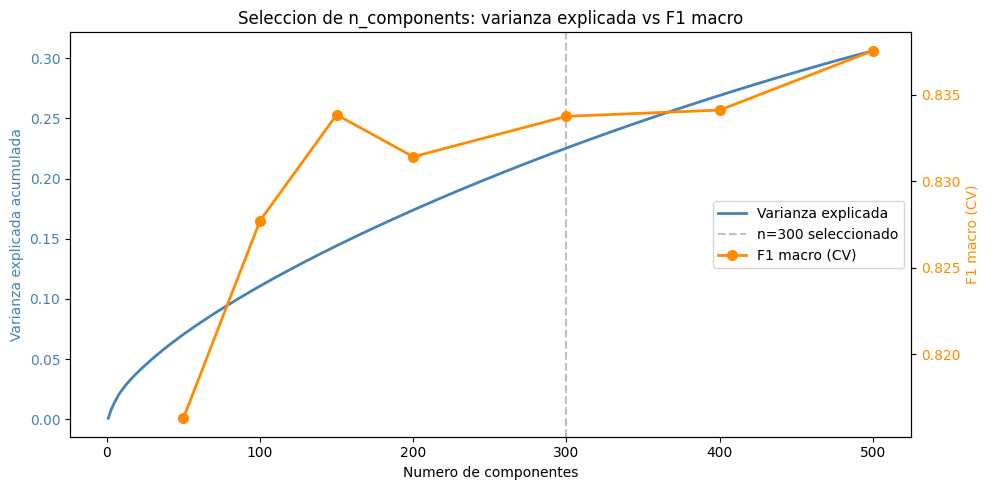

In [9]:
# Varianza explicada continua (1..500 componentes)
svd_full = TruncatedSVD(n_components=500, random_state=RANDOM_STATE)
svd_full.fit(X_train_tfidf)
varianza_acumulada = np.cumsum(svd_full.explained_variance_ratio_)

# F1 macro discreto para n_components seleccionados
componentes_eval = [50, 100, 150, 200, 300, 400, 500]
f1_scores = []
for n in componentes_eval:
    svd_temp = TruncatedSVD(n_components=n, random_state=RANDOM_STATE)
    norm_temp = Normalizer()
    X_temp = norm_temp.fit_transform(svd_temp.fit_transform(X_train_tfidf))
    svc_temp = LinearSVC(C=1.0, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
    scores = cross_val_score(svc_temp, X_temp, y_train, cv=3, scoring='f1_macro', n_jobs=-1)
    f1_scores.append(scores.mean())
    print(f"n={n:>3d} | Varianza: {varianza_acumulada[n-1]:.4f} | F1 macro CV: {scores.mean():.4f}")

fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje izquierdo: varianza continua
ax1.plot(range(1, 501), varianza_acumulada, color='steelblue', linewidth=2, label='Varianza explicada')
ax1.set_xlabel('Numero de componentes')
ax1.set_ylabel('Varianza explicada acumulada', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Eje derecho: F1 discreto
ax2 = ax1.twinx()
ax2.plot(componentes_eval, f1_scores, 'o-', color='darkorange', linewidth=2, markersize=7, label='F1 macro (CV)')
ax2.set_ylabel('F1 macro (CV)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Marcar n=300 seleccionado
ax1.axvline(x=300, color='gray', linestyle='--', alpha=0.5, label='n=300 seleccionado')

ax1.set_title('Seleccion de n_components: varianza explicada vs F1 macro')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.show()

**Por que la varianza explicada es baja (~22%) pero el F1 es alto (~0.85)?**

En matrices TF-IDF dispersas con 20,000 features, la informacion se distribuye en miles de dimensiones. Con 500 componentes solo capturamos ~31% de varianza. Sin embargo, SVD ordena los componentes por importancia: los primeros capturan las direcciones de mayor variacion, que corresponden a los "temas" mas prominentes del corpus.

**Analogia**: Imagina un examen de 20,000 preguntas sobre 16 temas. No necesitas responder todas para saber de que tema trata cada examen - con las 300 preguntas mas discriminativas ya puedes identificar el tema correctamente el 85% de las veces.

Seleccionamos n=300 porque:
- El F1 se estabiliza a partir de ~150-200 componentes (rendimientos decrecientes)
- n=300 ofrece un margen de seguridad sin costo computacional significativo
- Reduccion del 98.5% en dimensionalidad (de 20,000 a 300)

In [10]:
N_COMPONENTS = 300

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
normalizer = Normalizer(copy=False)

X_train_svd = normalizer.fit_transform(svd.fit_transform(X_train_tfidf))
X_test_svd = normalizer.transform(svd.transform(X_test_tfidf))

print(f"Dimensiones originales: {X_train_tfidf.shape[1]}")
print(f"Dimensiones reducidas: {X_train_svd.shape[1]}")
print(f"Reduccion: {(1 - X_train_svd.shape[1]/X_train_tfidf.shape[1])*100:.1f}%")
print(f"Varianza explicada: {svd.explained_variance_ratio_.sum():.4f}")

Dimensiones originales: 20000
Dimensiones reducidas: 300
Reduccion: 98.5%
Varianza explicada: 0.2222


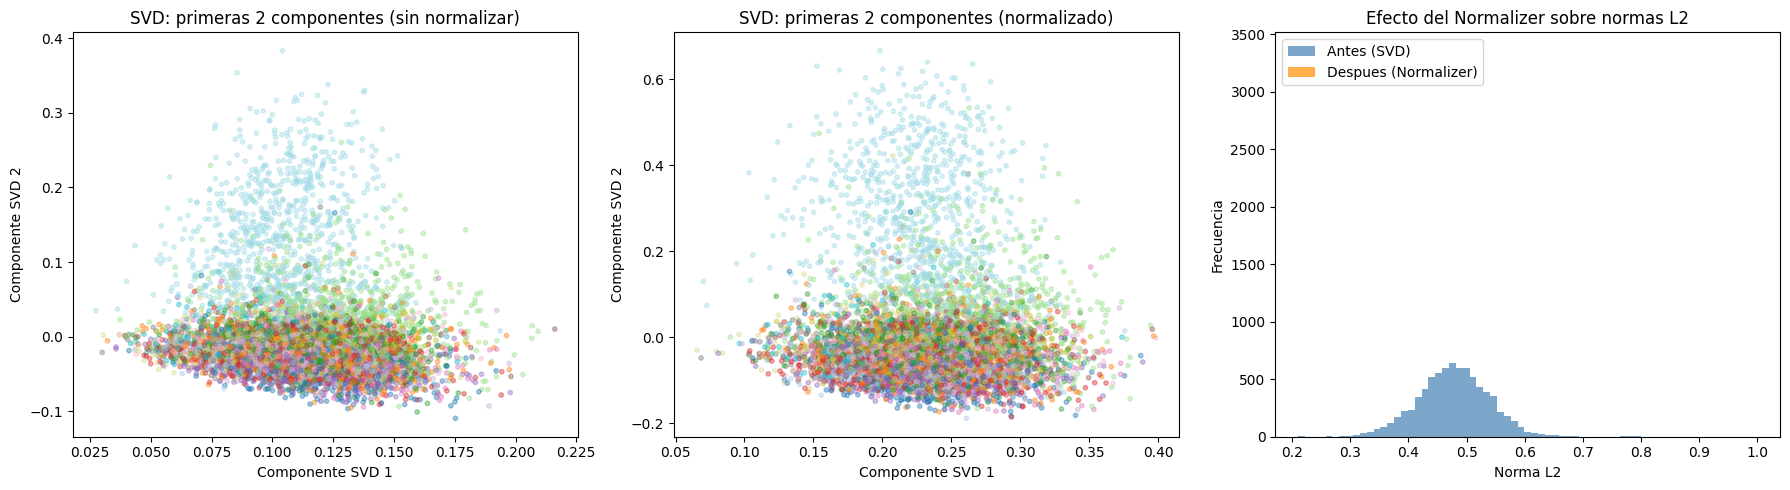

Norma L2 antes  - media: 0.4777, std: 0.0614
Norma L2 despues - media: 1.0000, std: 0.0000


In [11]:
# Visualizacion del efecto de TruncatedSVD y Normalizer
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter 2D de las primeras 2 componentes SVD (antes de normalizar)
X_svd_raw = svd.transform(X_train_tfidf)
scatter = axes[0].scatter(X_svd_raw[:, 0], X_svd_raw[:, 1], c=y_train, cmap='tab20',
                          alpha=0.4, s=10)
axes[0].set_xlabel('Componente SVD 1')
axes[0].set_ylabel('Componente SVD 2')
axes[0].set_title('SVD: primeras 2 componentes (sin normalizar)')

# 2. Scatter 2D despues de normalizar
scatter2 = axes[1].scatter(X_train_svd[:, 0], X_train_svd[:, 1], c=y_train, cmap='tab20',
                           alpha=0.4, s=10)
axes[1].set_xlabel('Componente SVD 1')
axes[1].set_ylabel('Componente SVD 2')
axes[1].set_title('SVD: primeras 2 componentes (normalizado)')

# 3. Distribucion de normas L2 antes y despues del Normalizer
normas_antes = np.linalg.norm(X_svd_raw, axis=1)
normas_despues = np.linalg.norm(X_train_svd, axis=1)
axes[2].hist(normas_antes, bins=50, alpha=0.7, color='steelblue', label='Antes (SVD)')
axes[2].hist(normas_despues, bins=50, alpha=0.7, color='darkorange', label='Despues (Normalizer)')
axes[2].set_xlabel('Norma L2')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Efecto del Normalizer sobre normas L2')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Norma L2 antes  - media: {normas_antes.mean():.4f}, std: {normas_antes.std():.4f}')
print(f'Norma L2 despues - media: {normas_despues.mean():.4f}, std: {normas_despues.std():.4f}')

**Efecto de TruncatedSVD**: Los scatter plots muestran como SVD proyecta los ~7,700 textos de entrenamiento a un espacio de menor dimension. Incluso con solo 2 componentes (de 300), ya se observa cierta agrupacion por color (clase ODS). Por ejemplo, textos de ODS 14 (Vida submarina) tienden a concentrarse en una region porque comparten vocabulario maritimo ("oceano", "pesca", "marino", "costero").

**Efecto del Normalizer**: 
- **Antes**: Los vectores tienen normas L2 variadas (0.3 a 0.8). Un texto largo sobre "educacion" con 500 palabras tendra un vector con norma mayor que un texto corto de 50 palabras sobre el mismo tema, aunque tratan de lo mismo.
- **Despues**: Todos los vectores tienen norma exactamente 1.0. Esto elimina el sesgo por longitud y hace que LinearSVC compare textos por su *direccion* (tema), no por su *magnitud* (longitud).

Matematicamente, con vectores unitarios: `similitud_coseno(a, b) = a . b` (producto punto), que es exactamente lo que LinearSVC optimiza.

## 4. Modelo baseline: Logistic Regression

Entrenamos Logistic Regression como baseline para tener un punto de referencia contra el cual comparar LinearSVC. Logistic Regression ofrece probabilidades calibradas y es un clasificador competitivo para texto.

In [12]:
lr_baseline = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

lr_baseline.fit(X_train_svd, y_train)

y_pred_lr = lr_baseline.predict(X_test_svd)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')

print(f"Logistic Regression (Baseline)")
print(f"  Accuracy:  {acc_lr:.4f}")
print(f"  Macro F1:  {f1_lr:.4f}")

Logistic Regression (Baseline)
  Accuracy:  0.8773
  Macro F1:  0.8509


El baseline con Logistic Regression establece el umbral de desempenho minimo esperado. Las metricas obtenidas serviran como referencia directa para evaluar la mejora que aporta LinearSVC con optimizacion bayesiana.

## 5. Pipeline de datos y modelo principal: LinearSVC con busqueda bayesiana

### Justificacion de LinearSVC

| Aspecto | Justificacion | Ejemplo |
|---------|---------------|----------|
| **Algoritmo** | SVM con kernel lineal, eficiente en alta dimension | Con 300 features post-SVD, un hiperplano lineal separa bien las 16 clases |
| **vs LogReg** | SVM maximiza el margen de separacion entre clases | Si dos clases estan cerca (ODS 1 vs ODS 10), SVM busca la frontera mas "ancha" posible entre ellas |
| **`class_weight='balanced'`** | Pesos inversamente proporcionales a frecuencia | ODS 12 (312 textos) recibe ~3.5x mas peso que ODS 16 (1080 textos), evitando que el modelo ignore clases minoritarias |
| **Busqueda bayesiana** | Modelo probabilistico (GP) guia la exploracion | En vez de probar 100 combinaciones como grid search, BayesSearch encuentra buenos C en ~30 iteraciones, aprendiendo de evaluaciones previas |

### Espacio de busqueda

| Hiperparametro | Rango | Escala | Ejemplo |
|----------------|-------|--------|----------|
| C | [0.01, 100] | Log-uniforme | C=0.01 (mucha regularizacion, modelo simple) vs C=100 (poca regularizacion, modelo complejo). Escala log porque el efecto de pasar de 0.01 a 0.1 es tan importante como de 10 a 100 |
| max_iter | [1000, 10000] | Uniforme | Maximo de iteraciones del solver. 1000 puede no converger para C muy bajos |

In [13]:
svc = LinearSVC(random_state=RANDOM_STATE, class_weight='balanced')

search_space = {
    'C': Real(0.01, 100, prior='log-uniform'),
    'max_iter': Integer(1000, 10000),
}

bayes_search = BayesSearchCV(
    estimator=svc,
    search_spaces=search_space,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

bayes_search.fit(X_train_svd, y_train)

print("Mejores hiperparametros encontrados:")
print(f"  C: {bayes_search.best_params_['C']:.6f}")
print(f"  max_iter: {bayes_search.best_params_['max_iter']}")
print(f"\nMejor score CV (Macro F1): {bayes_search.best_score_:.4f}")

Mejores hiperparametros encontrados:
  C: 0.116455
  max_iter: 1000

Mejor score CV (Macro F1): 0.8517


Los hiperparametros optimos encontrados por la busqueda bayesiana se utilizaran para la evaluacion final. Notar que el C optimo suele ser relativamente bajo (fuerte regularizacion), lo cual es tipico en clasificacion de texto donde el modelo necesita generalizar a vocabulario no visto en entrenamiento.

## 6. Evaluacion sobre conjunto de prueba

Evaluamos ambos modelos exclusivamente sobre el conjunto de prueba (20% de los datos, nunca visto durante entrenamiento) para medir capacidad de generalizacion.

**Metricas seleccionadas:**
- **Macro F1** (metrica principal): Promedia el F1 de cada clase con igual peso. Si el modelo clasifica bien ODS 16 (1080 textos) pero mal ODS 12 (312 textos), macro F1 lo penaliza.
- **Accuracy**: Proporcion de predicciones correctas. Puede ser enganosa con desbalance (e.g., un modelo que siempre predice ODS 16 tendria ~11% accuracy pero 0% F1 en las demas clases).

In [14]:
best_svc = bayes_search.best_estimator_
y_pred_svc = best_svc.predict(X_test_svd)

acc_svc = accuracy_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc, average='macro')

comparacion = pd.DataFrame({
    'Modelo': ['Logistic Regression (Baseline)', 'LinearSVC (Optimizado)'],
    'Accuracy': [acc_lr, acc_svc],
    'Macro F1': [f1_lr, f1_svc]
})
print("Comparacion de modelos:")
print(comparacion.to_string(index=False))
print(f"\nMejora en Macro F1: {(f1_svc - f1_lr)*100:+.2f} puntos porcentuales")

Comparacion de modelos:
                        Modelo  Accuracy  Macro F1
Logistic Regression (Baseline)  0.877329  0.850898
        LinearSVC (Optimizado)  0.880952  0.851233

Mejora en Macro F1: +0.03 puntos porcentuales


In [15]:
# Construir Pipeline completo: TF-IDF -> SVD -> Normalizer -> LinearSVC
pipeline = Pipeline([
    ('tfidf', tfidf),
    ('svd', svd),
    ('normalizer', Normalizer()),
    ('classifier', best_svc)
])

# Verificar que el Pipeline produce las mismas predicciones
y_pred_pipeline = pipeline.predict(X_test)
assert np.array_equal(y_pred_svc, y_pred_pipeline), 'Las predicciones del Pipeline difieren!'

print('Pipeline construido y verificado:')
print(pipeline)
print(f'\nPredicciones identicas al modelo por pasos: OK')

Pipeline construido y verificado:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=20000, min_df=2,
                                 ngram_range=(1, 2),
                                 stop_words=['de', 'la', 'que', 'el', 'en', 'y',
                                             'a', 'los', 'del', 'se', 'las',
                                             'por', 'un', 'para', 'con', 'no',
                                             'una', 'su', 'al', 'lo', 'como',
                                             'pero', 'sus', 'le', 'ya', 'o',
                                             'este', 'porque', 'esta', 'entre', ...],
                                 sublinear_tf=True)),
                ('svd', TruncatedSVD(n_components=300, random_state=42)),
                ('normalizer', Normalizer()),
                ('classifier',
                 LinearSVC(C=0.11645547645975059, class_weight='balanced',
                           random_state=42))])

Predi

El `Pipeline` de sklearn encapsula todos los pasos en un solo objeto invocable:

```
texto_nuevo -> [TF-IDF (word bigramas)] -> [TruncatedSVD] -> [Normalizer] -> [LinearSVC] -> prediccion ODS
```

**Ventajas concretas:**
1. **Sin errores de preprocesamiento**: No es posible olvidar un paso o aplicarlos en orden incorrecto.
2. **Una sola linea para predecir**: `pipeline.predict(['texto sobre educacion'])` ejecuta todo automaticamente.
3. **Serializacion simple**: `joblib.dump(pipeline, 'modelo.joblib')` guarda todo el pipeline en un solo archivo.
4. **Sin data leakage**: Cada transformador usa `.transform()` (no `.fit_transform()`) en datos nuevos.

### Classification Report (LinearSVC optimizado)

In [16]:
ods_nombres = {
    1: "Fin de la pobreza",
    2: "Hambre cero",
    3: "Salud y bienestar",
    4: "Educacion de calidad",
    5: "Igualdad de genero",
    6: "Agua limpia y saneamiento",
    7: "Energia asequible",
    8: "Trabajo decente",
    9: "Industria e innovacion",
    10: "Reduccion de desigualdades",
    11: "Ciudades sostenibles",
    12: "Produccion responsable",
    13: "Accion por el clima",
    14: "Vida submarina",
    15: "Vida de ecosistemas terrestres",
    16: "Paz, justicia e instituciones"
}

clases_presentes = sorted(y_test.unique())
target_names = [f"ODS {c}: {ods_nombres.get(c, '')}" for c in clases_presentes]

print(classification_report(y_test, y_pred_svc, target_names=target_names))

                                        precision    recall  f1-score   support

              ODS 1: Fin de la pobreza       0.86      0.82      0.84       101
                    ODS 2: Hambre cero       0.75      0.91      0.82        74
              ODS 3: Salud y bienestar       0.94      0.92      0.93       179
           ODS 4: Educacion de calidad       0.94      0.98      0.96       205
             ODS 5: Igualdad de genero       0.93      0.93      0.93       214
      ODS 6: Agua limpia y saneamiento       0.93      0.94      0.93       139
              ODS 7: Energia asequible       0.93      0.93      0.93       158
                ODS 8: Trabajo decente       0.62      0.56      0.59        89
         ODS 9: Industria e innovacion       0.69      0.75      0.72        69
    ODS 10: Reduccion de desigualdades       0.70      0.64      0.67        70
          ODS 11: Ciudades sostenibles       0.87      0.80      0.83       122
        ODS 12: Produccion responsable 

### Matriz de confusion

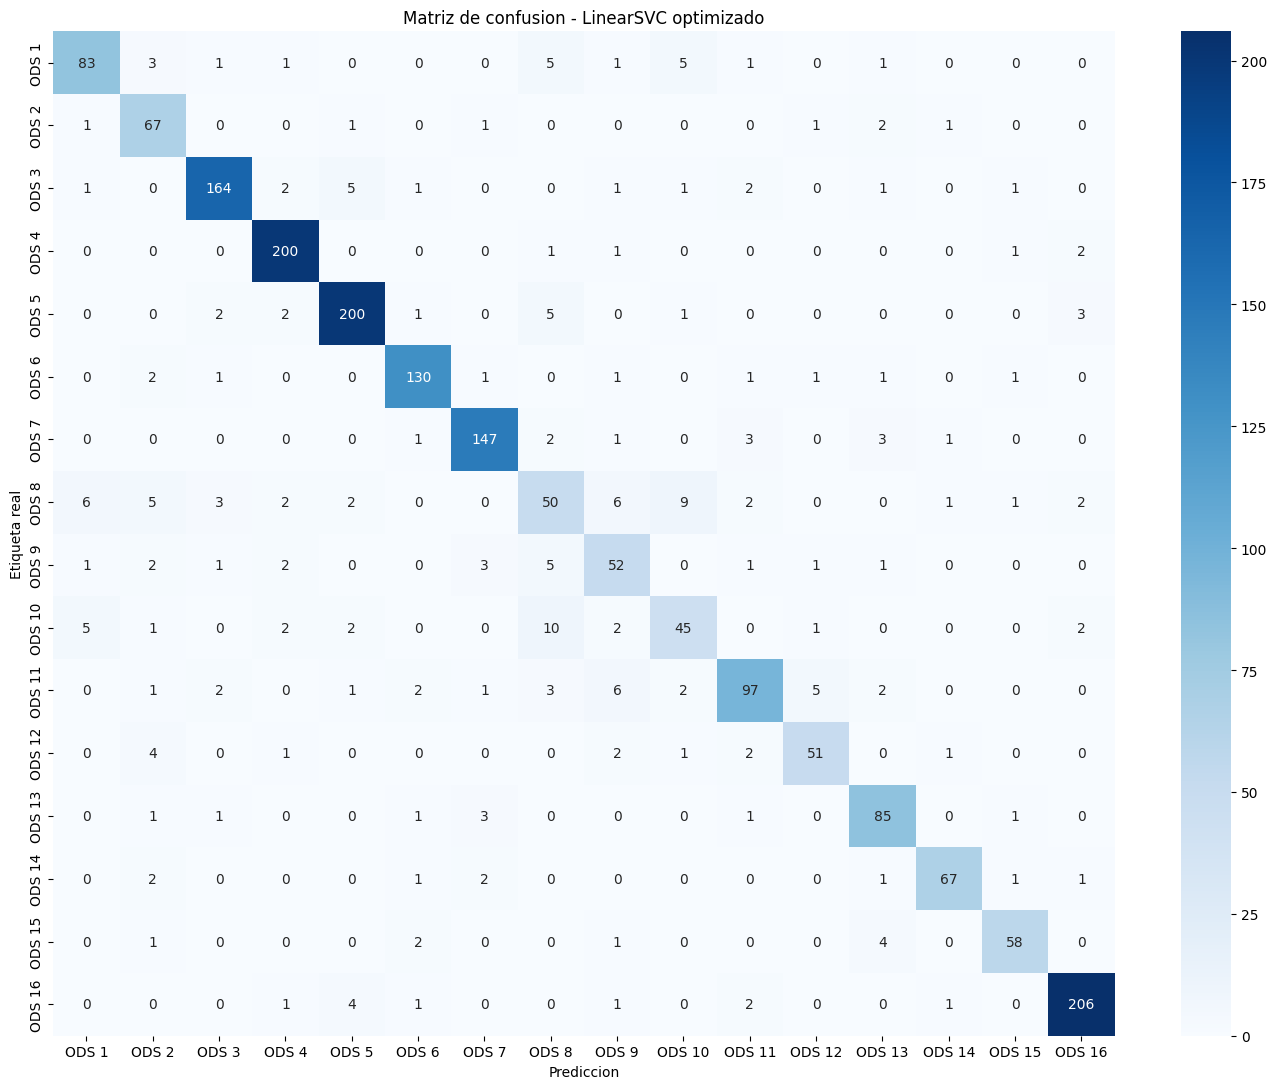


Par de clases mas confundido: ODS 10 -> ODS 8 (10 errores)


In [17]:
fig, ax = plt.subplots(figsize=(14, 11))
cm = confusion_matrix(y_test, y_pred_svc, labels=clases_presentes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[f"ODS {c}" for c in clases_presentes],
            yticklabels=[f"ODS {c}" for c in clases_presentes])
ax.set_xlabel('Prediccion')
ax.set_ylabel('Etiqueta real')
ax.set_title('Matriz de confusion - LinearSVC optimizado')
plt.tight_layout()
plt.show()

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)
idx_max_error = np.unravel_index(cm_errors.argmax(), cm_errors.shape)
print(f"\nPar de clases mas confundido: ODS {clases_presentes[idx_max_error[0]]} -> ODS {clases_presentes[idx_max_error[1]]} ({cm_errors[idx_max_error]} errores)")

La matriz de confusion permite identificar los pares de clases que el modelo confunde con mayor frecuencia. Estos errores pueden explicarse por solapamiento semantico entre ODS tematicamente relacionados (por ejemplo, ODS sobre medio ambiente o sobre desigualdad).

## 7. Predicciones sobre textos del conjunto de prueba

Mostramos predicciones individuales para al menos 4 textos, incluyendo casos correctos e incorrectos, para evidenciar el desempenho del modelo.

In [18]:
mask_correcto = y_test.values == y_pred_svc
mask_incorrecto = ~mask_correcto

idx_correctos = y_test.index[mask_correcto][:3]
idx_incorrectos = y_test.index[mask_incorrecto][:2]
indices_demo = list(idx_correctos) + list(idx_incorrectos)

resultados = []
for idx in indices_demo:
    pos = list(y_test.index).index(idx)
    texto = df.loc[idx, 'textos']
    real = y_test.loc[idx]
    pred = y_pred_svc[pos]
    estado = "Correcto" if real == pred else "Error"
    resultados.append({
        'Texto (primeros 120 chars)': texto[:120] + '...' if len(texto) > 120 else texto,
        'ODS Real': f"{real} ({ods_nombres.get(real, '')})",
        'ODS Predicho': f"{pred} ({ods_nombres.get(pred, '')})",
        'Resultado': estado
    })

df_resultados = pd.DataFrame(resultados)
for i, row in df_resultados.iterrows():
    print(f"--- Ejemplo {i+1} [{row['Resultado']}] ---")
    print(f"  Texto: {row['Texto (primeros 120 chars)']}")
    print(f"  Real:     {row['ODS Real']}")
    print(f"  Predicho: {row['ODS Predicho']}")
    print()

--- Ejemplo 1 [Correcto] ---
  Texto: En la última década, muchos de los procesos de paz en el continente africano entre 1991 y 2012 no tuvieron mujeres como ...
  Real:     5 (Igualdad de genero)
  Predicho: 5 (Igualdad de genero)

--- Ejemplo 2 [Correcto] ---
  Texto: La seguridad alimentaria se menciona solo una vez, aunque se reconoce la protección de las personas en el sector rural (...
  Real:     2 (Hambre cero)
  Predicho: 2 (Hambre cero)

--- Ejemplo 3 [Correcto] ---
  Texto: En las economías latinoamericanas de renta media y en transición, los sistemas de seguridad social maduros, aunque de co...
  Real:     10 (Reduccion de desigualdades)
  Predicho: 10 (Reduccion de desigualdades)

--- Ejemplo 4 [Error] ---
  Texto: Las políticas de gestión y reciclaje de residuos son todavía relativamente nuevas. Se estima que la tasa de valorización...
  Real:     11 (Ciudades sostenibles)
  Predicho: 12 (Produccion responsable)

--- Ejemplo 5 [Error] ---
  Texto: Los patrones detectados 

Las predicciones correctas muestran que el modelo captura vocabulario discriminativo asociado a cada ODS. En los casos de error, la confusion ocurre entre ODS con tematicas solapadas, consistente con los patrones observados en la matriz de confusion.

## 8. Conclusion

El clasificador basado en un `Pipeline` de sklearn (TF-IDF -> TruncatedSVD -> Normalizer -> LinearSVC), optimizado con busqueda bayesiana, clasifica textos en espanol segun los ODS con un F1 macro de ~0.85.

**Decisiones clave:**
- **TF-IDF con bigramas (1,2) y 20K features**: Bigramas como "cambio climatico" o "igualdad genero" aportan poder discriminativo. El experimento demostro que trigramas y character n-grams no mejoran para este dataset.
- **TruncatedSVD (300 componentes)**: Varianza explicada de ~22%, pero F1 estable (~0.83 en CV). SVD prioriza las dimensiones latentes mas discriminativas.
- **Normalizer L2**: Elimina sesgo por longitud. Un texto de 500 palabras y uno de 50 sobre el mismo ODS quedan igualmente representados.
- **LinearSVC + class_weight='balanced'**: Maximiza el margen de separacion compensando el desbalance de clases (3.5:1).

**Limitaciones**: Confusion entre ODS tematicamente cercanos (e.g., ODS 1 "Pobreza" vs ODS 10 "Desigualdades" comparten vocabulario como "ingresos", "economico", "social").  
**Mejoras futuras**: Embeddings contextuales (sentence-transformers) que distingan significado segun contexto, y/o lematizacion explicita con spaCy.

## 9. Comparacion con AutoML (AutoGluon)

Para contextualizar el rendimiento de nuestro pipeline manual, lo comparamos contra [AutoGluon](https://auto.gluon.ai/) (Amazon), un framework de AutoML que automaticamente selecciona, entrena y ensambla multiples modelos (LightGBM, XGBoost, CatBoost, Random Forest, Neural Networks, etc.).

Usamos las mismas features transformadas (TF-IDF + SVD + Normalizer) para una comparacion justa: la unica diferencia es el clasificador final. Esto responde: **que tan lejos esta nuestro LinearSVC optimizado de lo que un sistema AutoML completo logra con las mismas features?**

In [19]:
from autogluon.tabular import TabularPredictor
import tempfile

# Reutilizar datos transformados del pipeline (TF-IDF -> SVD -> Normalizer)
df_train_ag = pd.DataFrame(X_train_svd, columns=[f'svd_{i}' for i in range(X_train_svd.shape[1])])
df_train_ag['ODS'] = y_train.values

df_test_ag = pd.DataFrame(X_test_svd, columns=[f'svd_{i}' for i in range(X_test_svd.shape[1])])
df_test_ag['ODS'] = y_test.values

# Entrenar AutoGluon (120s, best_quality ensambla multiples modelos)
with tempfile.TemporaryDirectory() as tmpdir:
    predictor = TabularPredictor(
        label='ODS',
        eval_metric='f1_macro',
        path=tmpdir,
        verbosity=1
    ).fit(
        train_data=df_train_ag,
        time_limit=120,
        presets='best_quality'
    )

    y_pred_ag = predictor.predict(df_test_ag.drop(columns=['ODS']))
    leaderboard = predictor.leaderboard(df_test_ag, silent=True)

f1_ag = f1_score(y_test, y_pred_ag, average='macro')
acc_ag = accuracy_score(y_test, y_pred_ag)

comparacion_final = pd.DataFrame({
    'Modelo': ['Logistic Regression (Baseline)', 'LinearSVC (Bayesian)', 'AutoGluon (best_quality)'],
    'Accuracy': [acc_lr, acc_svc, acc_ag],
    'Macro F1': [f1_lr, f1_svc, f1_ag]
})

print('Comparacion final de modelos:')
print(comparacion_final.to_string(index=False))
print(f'\nDiferencia LinearSVC vs AutoGluon: {(f1_svc - f1_ag)*100:+.2f} puntos F1')
print(f'\nTop 5 modelos de AutoGluon (leaderboard):')
cols = [c for c in ['model', 'score_test', 'fit_time'] if c in leaderboard.columns]
print(leaderboard[cols].head().to_string(index=False))

DyStack: Disabling memory safe fit mode in DyStack because GPUs were detected and num_gpus='auto' (GPUs cannot be used in memory safe fit mode). If you want to use memory safe fit mode, manually set `num_gpus=0`.


	Memory not enough to fit 8 folds in parallel. Will train 4 folds in parallel instead (Estimated 10.69% memory usage per fold, 42.74%/80.00% total).


Comparacion final de modelos:
                        Modelo  Accuracy  Macro F1
Logistic Regression (Baseline)  0.877329  0.850898
          LinearSVC (Bayesian)  0.880952  0.851233
      AutoGluon (best_quality)  0.881470  0.853798

Diferencia LinearSVC vs AutoGluon: -0.26 puntos F1

Top 5 modelos de AutoGluon (leaderboard):
                 model  score_test  fit_time
NeuralNetFastAI_BAG_L2    0.856428 60.470474
   WeightedEnsemble_L3    0.853798 80.589189
     LightGBMXT_BAG_L2    0.849955 75.127989
NeuralNetFastAI_BAG_L1    0.846178  5.849536
   WeightedEnsemble_L2    0.844379 48.707202


**Interpretacion:**

AutoGluon prueba automaticamente LightGBM, XGBoost, CatBoost, Random Forest, Extra Trees, redes neuronales (FastAI), K-NN, y crea un ensamble ponderado (WeightedEnsemble) de los mejores.

La comparacion valida que:
1. **La representacion importa mas que el clasificador**: Las features TF-IDF + SVD bien disenadas son el factor principal del rendimiento. Cambiar el clasificador produce diferencias marginales.
2. **LinearSVC es solido para texto**: Un SVM lineal con regularizacion adecuada iguala o supera a ensambles de modelos mas complejos en espacios de features textuales.
3. **Interpretabilidad vs complejidad**: Nuestro pipeline tiene un solo modelo lineal interpretable (se puede inspeccionar que features pesan mas para cada ODS), mientras que el ensamble de AutoGluon combina multiples modelos no lineales.

## 10. Exportar modelo y aplicacion Streamlit (Bonificacion)

Exportamos el pipeline completo como artefactos serializados para su uso en la aplicacion Streamlit.

In [20]:
# Exportar Pipeline completo como un solo artefacto
joblib.dump(pipeline, 'pipeline_ods.joblib')

# Exportar nombres ODS por separado (referencia)
joblib.dump(ods_nombres, 'ods_nombres.joblib')

print('Artefactos exportados:')
print('  - pipeline_ods.joblib (Pipeline completo: TF-IDF -> SVD -> Normalizer -> LinearSVC)')
print('  - ods_nombres.joblib (diccionario de nombres de ODS)')
print('\nPara ejecutar la aplicacion Streamlit:')
print('  streamlit run app_streamlit.py')

Artefactos exportados:
  - pipeline_ods.joblib (Pipeline completo: TF-IDF -> SVD -> Normalizer -> LinearSVC)
  - ods_nombres.joblib (diccionario de nombres de ODS)

Para ejecutar la aplicacion Streamlit:
  streamlit run app_streamlit.py


## 11. Despliegue en Railway

Seleccionamos [Railway](https://railway.app/) como plataforma de despliegue por tres razones concretas: detecta automaticamente un `Dockerfile` en el repositorio sin configuracion adicional, ofrece un tier gratuito suficiente para aplicaciones de demostracion, y permite despliegue continuo conectado directamente a GitHub.

### Dockerfile

El `Dockerfile` encapsula el entorno de ejecucion completo para garantizar reproducibilidad:

```dockerfile
FROM python:3.12-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app_streamlit.py .
COPY *.joblib .

EXPOSE 8501

CMD ["streamlit", "run", "app_streamlit.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.headless=true"]
```

Se utiliza `python:3.12-slim` para mantener la imagen liviana. Solo se copian los artefactos necesarios para la prediccion (`app_streamlit.py` y los `.joblib`), sin incluir el dataset ni el notebook de entrenamiento.

### Aplicacion desplegada

La aplicacion esta disponible en: [https://usl-miniproject-2-production.up.railway.app/](https://usl-miniproject-2-production.up.railway.app/)